# Eswatini Drought Hub — SOP Library & Detailed Insights

Companion to `eswatini_drought_analysis.ipynb` (which covers the real CDI raster / vector / weather-station data).
This notebook analyses the **new prototype sections** added to `index.html`:

- **Detailed Insights → Priority areas**: the 6-indicator priority model `Priority = Drought × Exposure × Vulnerability × 10`
- **SOP Library**: rule-based Standard Operating Procedures with trigger conditions evaluated per Inkhundla
- **Drought Review queue**: satellite × station deltas + IKS signals → suggested D-class adjustments
- **IKS Explorer** and **CDI Explorer** time series

All datasets were extracted from the prototype with `scripts/extract_prototype_data.mjs`, which runs the page's *own*
JavaScript functions (`buildPriorityData()`, `sopSeedLibrary()`, every SOP `trigger()`) in Node — so the values here are
exactly what the UI computes. We then **reimplement each formula in Python and verify it reproduces the extracted values**.

In [1]:
import json
from pathlib import Path

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

P = Path('data/prototype')

pa = pd.read_csv(P / 'priority_areas.csv')
params = json.loads((P / 'priority_model_params.json').read_text())
sops = pd.read_csv(P / 'sop_library.csv')
act = pd.read_csv(P / 'sop_activation_matrix.csv')
rq = pd.read_csv(P / 'review_queue.csv')
series = pd.read_csv(P / 'cdi_explorer_series.csv')
iks = json.loads((P / 'iks_data.json').read_text())
iks_ind = pd.read_csv(P / 'iks_indicators.csv')

print(f'{len(pa)} Tinkhundla · {len(sops)} SOPs · {len(act)} trigger evaluations · {len(rq)} review rows · {len(series)} series points')
print('\nPriority model:', params['formula'])
print('  ', params['exposure'])
print('  ', params['vulnerability'])

59 Tinkhundla · 7 SOPs · 413 trigger evaluations · 59 review rows · 7080 series points

Priority model: priority = droughtScore * exposureScore * vulnScore * 10
   exposureScore = 0.6 * popNorm + 0.4 * rainfedNorm; popWeighted = pop + 0.5 * u5
   vulnScore = (vWater + vIpc + vPrep) / 3


## 1. Priority Areas — the 6-indicator model

$$\text{Priority} = \underbrace{D_{norm}}_{\text{drought}} \times \underbrace{(0.6\,\text{pop}_{norm} + 0.4\,\text{rainfed}_{norm})}_{\text{exposure}} \times \underbrace{\tfrac{v_{water}+v_{ipc}+v_{prep}}{3}}_{\text{vulnerability}} \times 10$$

with $\text{pop}_{weighted} = \text{pop} + 0.5\cdot U5$ (children under five weighted ×1.5), capped at 15 000;
rain-fed cropland = cropland × rain-fed share, capped at 5 000 ha; $v_{water} = \min(1, \text{people-per-water-point}/500)$.

Action bands: **urgent** > 4.5 · **watch** > 2.5 · **monitor** otherwise.

First: reimplement in Python from the raw sub-indicators and verify against the prototype's own output.

In [2]:
D_NORM = params['d_norm']
CAPS = params['caps']


def priority_score(row: pd.Series) -> pd.Series:
    """Python port of buildPriorityData() core maths in index.html."""
    drought = D_NORM.get(row['dclass'], 0.4)
    pop_norm = min(1.0, (row['pop'] + 0.5 * row['u5']) / CAPS['pop'])
    rainfed_norm = min(1.0, round(row['cropland'] * row['rfShare']) / CAPS['rainfed_ha'])
    exposure = 0.6 * pop_norm + 0.4 * rainfed_norm
    vuln = (row['vWater'] + row['vIpc'] + row['vPrep']) / 3
    return pd.Series({'py_priority': drought * exposure * vuln * 10,
                      'py_exposure': exposure, 'py_vuln': vuln})


check = pa.join(pa.apply(priority_score, axis=1))
for col, ref in [('py_priority', 'priorityScore'), ('py_exposure', 'exposureScore'), ('py_vuln', 'vulnScore')]:
    diff = (check[col] - check[ref]).abs().max()
    print(f'{ref:>14}: max |Python - prototype| = {diff:.2e}')

top = pa.nlargest(12, 'priorityScore')
top[['rank', 'name', 'region', 'dclass', 'priorityScore', 'droughtScore', 'exposureScore', 'vulnScore', 'action', 'pop', 'peoplePerWP']].round(3)

 priorityScore: max |Python - prototype| = 2.22e-16
 exposureScore: max |Python - prototype| = 5.55e-17
     vulnScore: max |Python - prototype| = 1.11e-16


,rank,name,region,dclass,priorityScore,droughtScore,exposureScore,vulnScore,action,pop,peoplePerWP
0,1,Nkwene,Shiselweni,D3,2.387,0.8,0.447,0.667,monitor,8956,2239.000
1,2,Hosea,Shiselweni,D3,2.317,0.8,0.401,0.723,monitor,5564,618.222
2,3,Sigwe,Shiselweni,D2,2.202,0.6,0.506,0.726,monitor,8836,981.778
3,4,Kumethula,Shiselweni,D3,1.871,0.8,0.449,0.521,monitor,4860,270.000
4,5,Lubuli,Lubombo,D2,1.845,0.6,0.430,0.715,monitor,5924,370.250
5,6,Gege,Shiselweni,D3,1.768,0.8,0.302,0.732,monitor,5820,323.333
6,7,Ngudzeni,Shiselweni,D2,1.764,0.6,0.509,0.578,monitor,7324,366.200
7,8,Sithobela,Lubombo,D2,1.639,0.6,0.426,0.641,monitor,3620,402.222
8,9,Siphofaneni,Lubombo,D2,1.624,0.6,0.406,0.667,watch,5100,340.000
9,10,Somntongo,Shiselweni,D2,1.487,0.6,0.295,0.839,monitor,5532,691.500


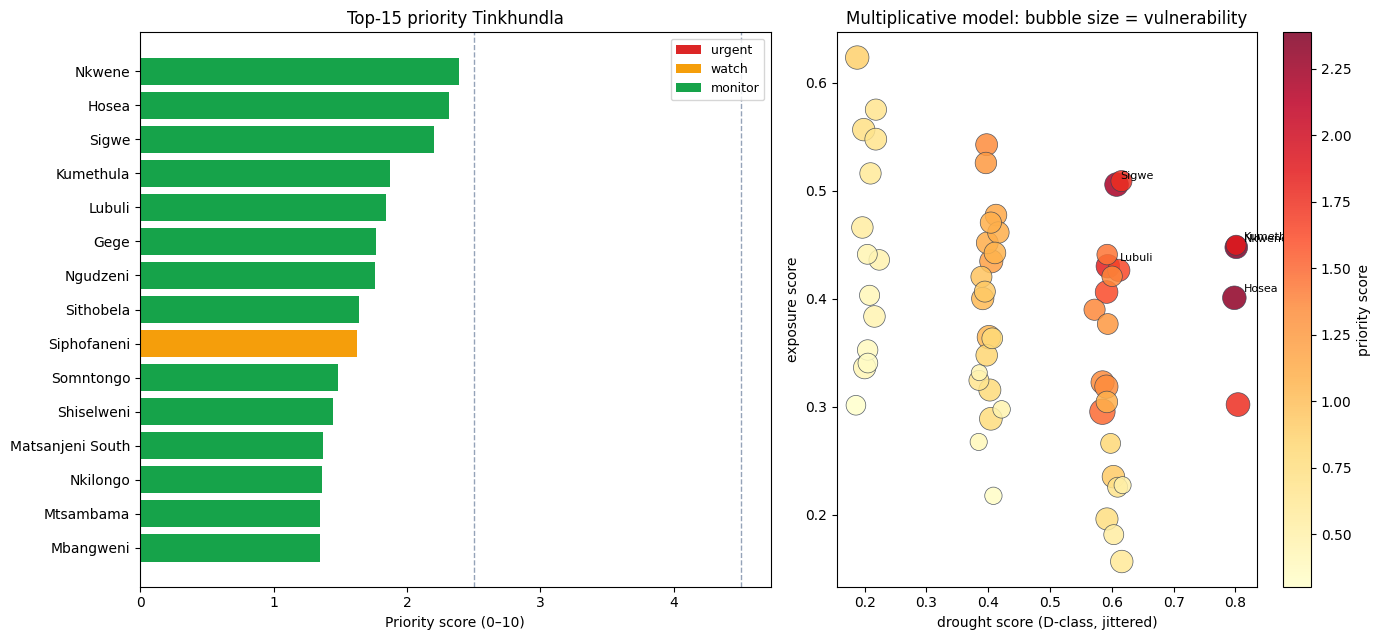

In [3]:
ACTION_COLORS = {'urgent': '#dc2626', 'watch': '#f59e0b', 'monitor': '#16a34a'}

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), width_ratios=[1.2, 1])
t15 = pa.nlargest(15, 'priorityScore').iloc[::-1]
axes[0].barh(t15['name'], t15['priorityScore'], color=t15['action'].map(ACTION_COLORS))
axes[0].set_xlabel('Priority score (0–10)')
axes[0].set_title('Top-15 priority Tinkhundla')
axes[0].legend(handles=[Patch(facecolor=c, label=a) for a, c in ACTION_COLORS.items()], fontsize=9)
for thr in (2.5, 4.5):
    axes[0].axvline(thr, color='#94a3b8', linestyle='--', linewidth=1)

sc = axes[1].scatter(pa['droughtScore'] + np.random.default_rng(0).normal(0, 0.012, len(pa)),
                     pa['exposureScore'], s=pa['vulnScore'] * 400,
                     c=pa['priorityScore'], cmap='YlOrRd', edgecolor='#374151', linewidth=0.5, alpha=0.85)
plt.colorbar(sc, ax=axes[1], label='priority score')
axes[1].set_xlabel('drought score (D-class, jittered)')
axes[1].set_ylabel('exposure score')
axes[1].set_title('Multiplicative model: bubble size = vulnerability')
for _, r in pa.nlargest(5, 'priorityScore').iterrows():
    axes[1].annotate(r['name'], (r['droughtScore'], r['exposureScore']), fontsize=8,
                     xytext=(6, 4), textcoords='offset points')
plt.tight_layout()
plt.show()

matched 59 / 59 polygons by name


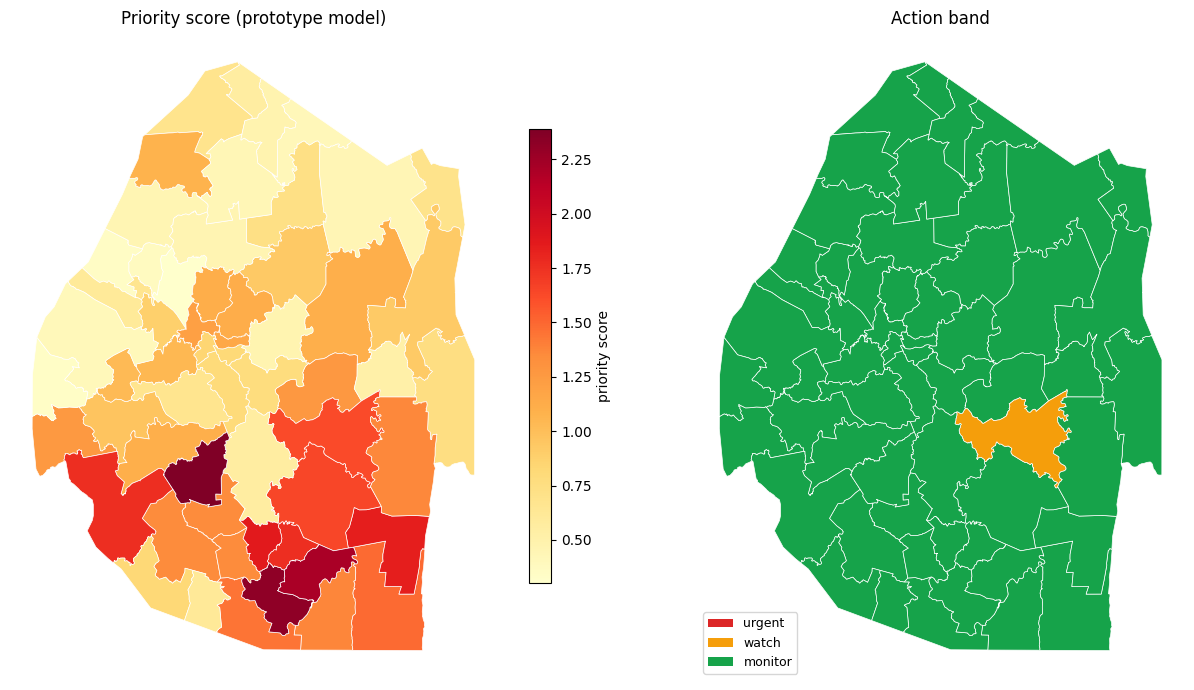

In [4]:
# Join the priority scores onto the real Tinkhundla polygons (resources/)
gdf = gpd.read_file('resources/cdi_map_2025-07.geojson')
m = gdf.merge(pa[['name', 'priorityScore', 'action']], on='name', how='left')
print(f"matched {m['priorityScore'].notna().sum()} / {len(m)} polygons by name")

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
m.plot(ax=axes[0], column='priorityScore', cmap='YlOrRd', legend=True,
       edgecolor='white', linewidth=0.5, missing_kwds={'color': '#e5e7eb'},
       legend_kwds={'shrink': 0.7, 'label': 'priority score'})
axes[0].set_title('Priority score (prototype model)')
axes[0].set_axis_off()
m.plot(ax=axes[1], color=m['action'].map(ACTION_COLORS).fillna('#e5e7eb'), edgecolor='white', linewidth=0.5)
axes[1].set_title('Action band')
axes[1].legend(handles=[Patch(facecolor=c, label=a) for a, c in ACTION_COLORS.items()], loc='lower left', fontsize=9)
axes[1].set_axis_off()
plt.tight_layout()
plt.show()

## 2. SOP Library — rule-based action triggers

Each SOP carries a machine-readable trigger over the priority-model fields, e.g. `SOP-WASH-3`: *D2+ AND vWater ≥ 0.65 AND pop ≥ 2 500*.
The extractor ran every `trigger(d)` function against all 59 Tinkhundla → `sop_activation_matrix.csv`.

We re-encode the trigger rules in Python and check we reproduce the prototype's activation decisions exactly.

In [5]:
display(sops[['id', 'title', 'sector', 'timing', 'triggerDclass', 'triggerVulnIndicator',
              'triggerVulnValue', 'triggerExpIndicator', 'triggerExpValue', 'owner', 'status']])

# Python re-encoding of the JS trigger() functions (from index.html ACTION_TEMPLATES)
TRIGGERS = {
    'SOP-WASH-3': lambda d: d.droughtScore >= 0.6 and d.vWater >= 0.65 and d.pop >= 2500,
    'SOP-WASH-1': lambda d: d.droughtScore >= 0.8 and d.vWater >= 0.75,
    'SOP-AG-2':   lambda d: d.droughtScore >= 0.6 and d.livestock >= 1500 and d.vIpc >= 0.60,
    'SOP-AG-4':   lambda d: d.droughtScore >= 0.7 and d.rainfedCropland >= 1500 and d.vIpc >= 0.55,
    'SOP-ECO-2':  lambda d: d.droughtScore >= 0.7 and d.rangeland >= 3000 and d.livestock >= 1500,
    'SOP-PREP-1': lambda d: d.priorityScore >= 3.0 and d.vPrep >= 0.55,
    'SOP-PREP-3': lambda d: d.droughtScore >= 0.6 and d.u5 >= 300 and d.vIpc >= 0.55,
}

pred = [{'inkhundla': d.name, 'sop_id': sid, 'py_triggered': int(fn(d))}
        for d in pa.itertuples() for sid, fn in TRIGGERS.items()]
cmp_df = act.merge(pd.DataFrame(pred), on=['inkhundla', 'sop_id'])
mismatch = cmp_df[cmp_df['triggered'] != cmp_df['py_triggered']]
print(f'\nPython vs prototype trigger decisions: {len(cmp_df) - len(mismatch)}/{len(cmp_df)} match', 
      f'({len(mismatch)} mismatches)' if len(mismatch) else '— exact reproduction')
if len(mismatch):
    display(mismatch)

,id,title,sector,timing,triggerDclass,triggerVulnIndicator,triggerVulnValue,triggerExpIndicator,triggerExpValue,owner,status
0,SOP-WASH-3,Borehole reinforcement & monitoring,wash,immediate,D2+,vWater,0.65,pop,2500.0,DWA + Inkhundla Indvuna,active
1,SOP-WASH-1,Water-trucking pre-positioning,wash,immediate,D3+,vWater,0.75,none,NaN,Eswatini Water Services + Red Cross,active
2,SOP-AG-2,Livestock-offtake subsidy activation,ag,immediate,D2+,vestock,1.00,livestock,1500.0,MoA Livestock Officer,active
3,SOP-AG-4,Seed distribution for next planting,ag,thismonth,D2+,vIpc,0.55,cropland,1500.0,MoA Crop Officer + Inkhundla Indvuna,active
4,SOP-ECO-2,Rangeland rest rotation,eco,thismonth,D2+,vestock,1.00,rangeland,3000.0,Inkhundla chief + MoA range officer,active
5,SOP-PREP-1,Activate Inkhundla DRMC,prep,immediate,D2+,vPrep,0.55,none,NaN,Inkhundla chief + NDMA regional coordinator,active
6,SOP-PREP-3,Social-protection seasonal top-up,prep,thismonth,D2+,vIpc,0.55,u5,300.0,DPMO + Inkhundla Indvuna,active



Python vs prototype trigger decisions: 413/413 match — exact reproduction


18 of 59 Tinkhundla trigger at least one SOP · 36 activations total


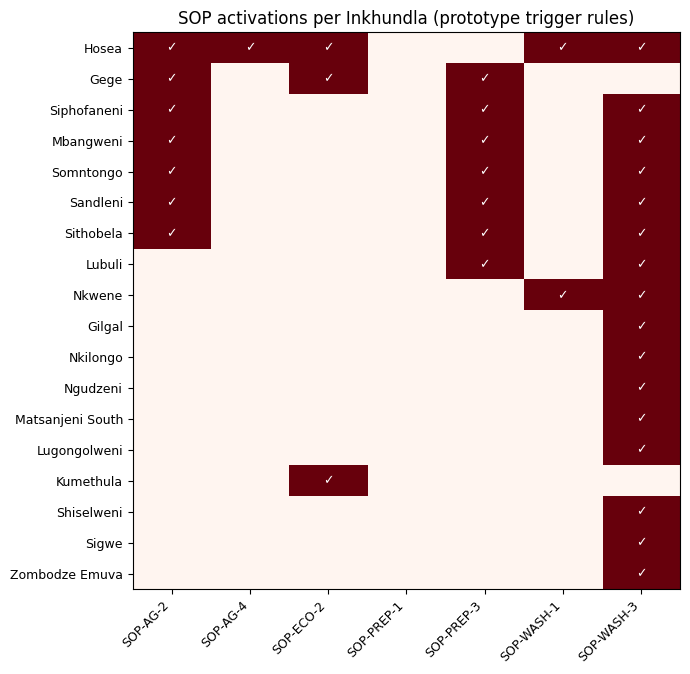


Activations by sector:
sector
ag       8
eco      3
prep     7
wash    18


In [6]:
wide = act.pivot_table(index='inkhundla', columns='sop_id', values='triggered')
wide['total'] = wide.sum(axis=1)
hot = wide[wide['total'] > 0].sort_values('total', ascending=False)
print(f'{len(hot)} of {len(wide)} Tinkhundla trigger at least one SOP · {int(act.triggered.sum())} activations total')

fig, ax = plt.subplots(figsize=(7, max(4, 0.38 * len(hot))))
sop_cols = [c for c in hot.columns if c != 'total']
im = ax.imshow(hot[sop_cols].values, cmap='Reds', aspect='auto', vmin=0, vmax=1)
ax.set_xticks(range(len(sop_cols)), sop_cols, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(hot)), hot.index, fontsize=9)
for (i, j), v in np.ndenumerate(hot[sop_cols].values):
    if v:
        ax.text(j, i, '✓', ha='center', va='center', color='white', fontsize=9, fontweight='bold')
ax.set_title('SOP activations per Inkhundla (prototype trigger rules)')
plt.tight_layout()
plt.show()

sector_counts = act[act['triggered'] == 1].groupby('sector').size()
print('\nActivations by sector:')
print(sector_counts.to_string())

## 3. Drought Review queue — satellite × station deltas + IKS

`RQ_DATA` now carries full numeric values per Inkhundla: satellite SPI/LST, station SPI/LST, their deltas,
a combined delta, station-confidence tier, IKS field signals, and a *suggested* D-class that may be
**bumped** ±1 class when the station disagrees with the satellite.

Let's discover which formula the combined delta actually uses, and verify the confidence banding and bump logic.

In [7]:
rq['abs_spi_d'] = (rq['sat_spi'] - rq['sta_spi']).abs()
rq['abs_lst_d'] = (rq['sat_lst'] - rq['sta_lst']).abs()

cand = {
    '|dSPI| + |dLST|':     rq['abs_spi_d'] + rq['abs_lst_d'],
    '|dSPI| + |dLST|/2':   rq['abs_spi_d'] + rq['abs_lst_d'] / 2,
    'spi_delta + lst_delta (stored)': rq['spi_delta'] + rq['lst_delta'],
}
print('Which formula reproduces combined_delta?')
for label, vals in cand.items():
    err = (vals - rq['combined_delta']).abs().max()
    print(f'  {label:<34} max error = {err:.4f}')


def confidence_tier(combined: float) -> str:
    """Station-confidence banding used by the review queue."""
    if combined < 0.50:
        return 'High'
    if combined < 1.00:
        return 'Medium'
    return 'Low'


rq['py_conf'] = rq['combined_delta'].apply(confidence_tier)
match = (rq['py_conf'] == rq['station_confidence']).mean() * 100
print(f'\nConfidence banding (<0.5 High, <1.0 Medium, else Low) reproduces stored tier: {match:.0f}%')

D_ORDER = ['None', 'D0', 'D1', 'D2', 'D3', 'D4']
rank = {d: i for i, d in enumerate(D_ORDER)}
rq['bump'] = rq['suggested_value'].map(rank) - rq['cdi_class'].map(rank)
print('\nSuggested-value bump vs station direction:')
display(pd.crosstab(rq['direction'].fillna('aligned'), rq['bump'], margins=True))

Which formula reproduces combined_delta?
  |dSPI| + |dLST|                    max error = 0.0000
  |dSPI| + |dLST|/2                  max error = 0.3500
  spi_delta + lst_delta (stored)     max error = 0.0000

Confidence banding (<0.5 High, <1.0 Medium, else Low) reproduces stored tier: 100%

Suggested-value bump vs station direction:


bump,-1,0,1,All
direction,,,,
aligned,0,12,0,12
drier,0,22,2,24
wetter,4,19,0,23
All,4,53,2,59


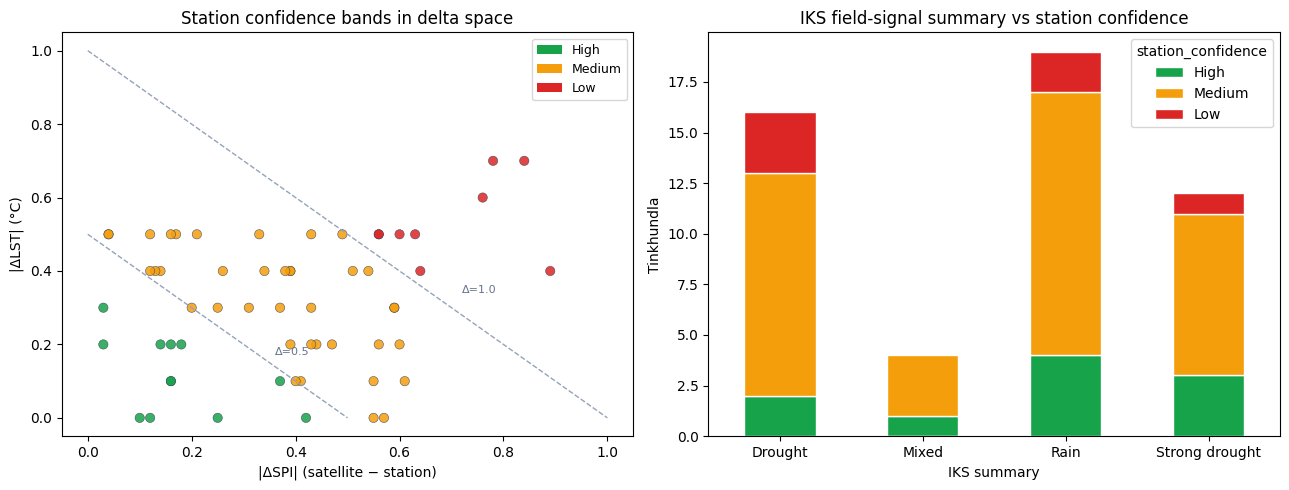

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
CONF_COLORS = {'High': '#16a34a', 'Medium': '#f59e0b', 'Low': '#dc2626'}
axes[0].scatter(rq['spi_delta'], rq['lst_delta'], c=rq['station_confidence'].map(CONF_COLORS),
                s=45, edgecolor='#374151', linewidth=0.4, alpha=0.85)
for thr in (0.5, 1.0):
    x = np.linspace(0, thr, 50)
    axes[0].plot(x, thr - x, '--', color='#94a3b8', linewidth=1)
    axes[0].text(thr * 0.72, thr * 0.34, f'Δ={thr}', fontsize=8, color='#64748b')
axes[0].set_xlabel('|ΔSPI| (satellite − station)')
axes[0].set_ylabel('|ΔLST| (°C)')
axes[0].set_title('Station confidence bands in delta space')
axes[0].legend(handles=[Patch(facecolor=c, label=t) for t, c in CONF_COLORS.items()], fontsize=9)

iks_ct = pd.crosstab(rq['iks_summary'], rq['station_confidence'])[['High', 'Medium', 'Low']]
iks_ct.plot(kind='bar', stacked=True, ax=axes[1], color=[CONF_COLORS[c] for c in iks_ct.columns], edgecolor='white')
axes[1].set_title('IKS field-signal summary vs station confidence')
axes[1].set_xlabel('IKS summary')
axes[1].set_ylabel('Tinkhundla')
axes[1].tick_params(axis='x', rotation=0)
plt.tight_layout()
plt.show()

## 4. IKS Explorer — indigenous knowledge signals

Weekly net drought-signal counts per region, plus the catalogue of traditional rainfall/seasonal indicators
the prototype tracks (with their satellite-agreement statistics).

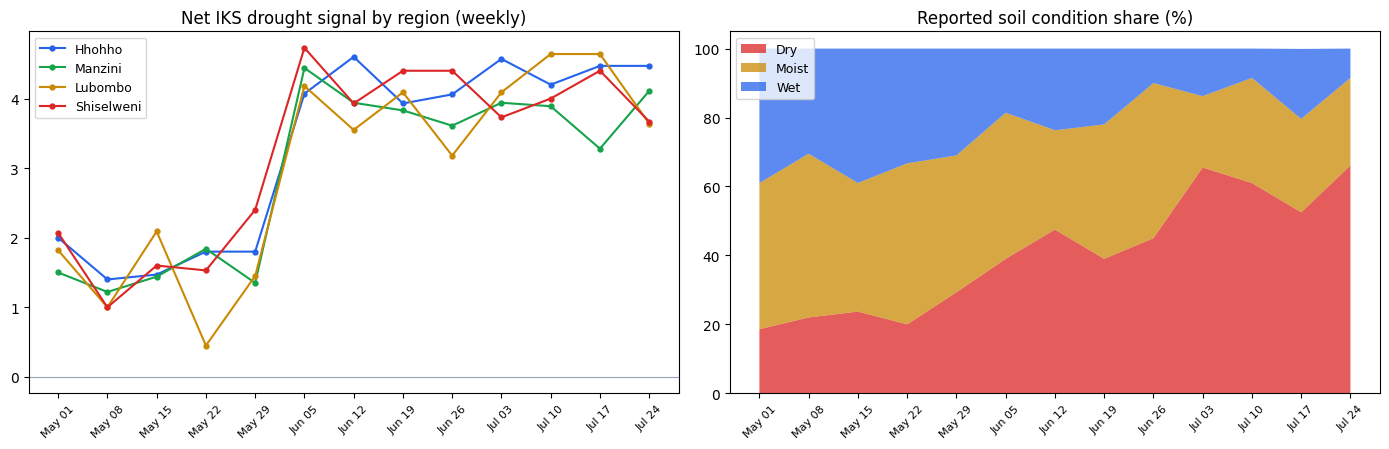

IKS indicator catalogue (top 10 by reports):


,type,code,en,si,group,pol
0,rainfall,BS,Blue Swallows appearing,Tinkonjane tiyabonakala,birds,rain
1,rainfall,SG,Southern Ground-Hornbill calling,Insingizi ikhala,birds,rain
2,rainfall,AFE,African Fish Eagle calling,Inkwazi ikhala,birds,rain
3,rainfall,BC,Burchell's Coucal calling,Umfuku ukhala,birds,rain
4,rainfall,RCC,Red-chested Cuckoo calling,Phezukomkhono akhala,birds,rain
5,rainfall,JC,Jacobin Cuckoo calling,Inkanku ikhala,birds,rain
6,rainfall,EBE,European Bee-eater calling,Umhlolamvula ukhala,birds,rain
7,rainfall,LB,Lightning bird (Tsekwane) calling,Tsekwane akhala,birds,rain
8,rainfall,F,Frogs calling,Emacoco akhala,insects,rain
9,rainfall,C,Caterpillars in abundance,Tibungu letinyenti,insects,rain


In [9]:
RGN_COLORS = {'Hhohho': '#2563eb', 'Manzini': '#16a34a', 'Lubombo': '#ca8a04', 'Shiselweni': '#dc2626'}
weeks = iks['weeks']

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6))
for region, vals in iks['trend'].items():
    axes[0].plot(weeks, vals, marker='o', markersize=3.5, label=region, color=RGN_COLORS.get(region))
axes[0].set_title('Net IKS drought signal by region (weekly)')
axes[0].tick_params(axis='x', rotation=45, labelsize=8)
axes[0].legend(fontsize=9)
axes[0].axhline(0, color='#94a3b8', linewidth=0.8)

soil = iks['soil_trend']
axes[1].stackplot(weeks, soil['dry'], soil['moist'], soil['wet'],
                  labels=['Dry', 'Moist', 'Wet'], colors=['#dc2626', '#ca8a04', '#2563eb'], alpha=0.75)
axes[1].set_title('Reported soil condition share (%)')
axes[1].tick_params(axis='x', rotation=45, labelsize=8)
axes[1].legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

print('IKS indicator catalogue (top 10 by reports):')
cols = [c for c in ['type', 'name', 'meaning', 'reports', 'agreement'] if c in iks_ind.columns]
display(iks_ind.sort_values('reports', ascending=False)[cols].head(10) if 'reports' in iks_ind.columns else iks_ind.head(10))

### 4b. Real IKS data — KoboToolbox form + submissions

`resources/` now contains the **actual IKS collection instrument**:

- `IKS_KoboForm_a3ytas3GLhSewNTZByCCsd.xlsx` — the XLSForm: 21 rainfall-prediction indicators (B1), 8 seasonal/extreme-event indicators (C1), soil-moisture (D1) and vegetation-greenness (D2) observations, bilingual English/siSwati
- `IKS_KoboDummyData_2026-05-11-06-38-25.xlsx` — 107 test submissions (7–11 May 2026)

**Caveat:** the dummy submissions carry Faker-generated constituency names ("Akvo Foundation", "Beard LLC", …) — 0 of 106 match real Tinkhundla, so per-Inkhundla maps and CDI-agreement checks must wait for real submissions. What *is* analysable now: the indicator catalogue (vs the prototype's), selection frequencies, soil/vegetation distributions, and the net drought-vs-rain signal.

In [10]:
import re

FORM = Path('resources/IKS_KoboForm_a3ytas3GLhSewNTZByCCsd.xlsx')
SUBS = Path('resources/IKS_KoboDummyData_2026-05-11-06-38-25.xlsx')

choices = pd.read_excel(FORM, sheet_name='choices')
label_col = [c for c in choices.columns if str(c).startswith('label')][0]

# B1 list (do2ug34) = rainfall indicators; C1 list (fg74l33) = seasonal indicators
kobo_cat = choices[choices['list_name'].isin(['do2ug34', 'fg74l33'])].copy()
kobo_cat['group'] = kobo_cat['list_name'].map({'do2ug34': 'rainfall', 'fg74l33': 'seasonal'})
kobo_cat['code'] = (kobo_cat['name'].str.extract(r'^\d+__([a-z_]+?)___')[0]
                    .str.upper().str.replace('_', '/', regex=False))
kobo_cat['label_en'] = kobo_cat[label_col].str.replace(r'\s*\(.*\)\s*$', '', regex=True)

proto_cat = pd.read_csv('data/prototype/iks_indicators.csv')
proto_cat['pol'] = proto_cat['pol'].replace({'drt': 'drought'})  # normalise prototype shorthand
matched = kobo_cat.merge(proto_cat[['code', 'pol', 'type']].drop_duplicates('code'), on='code', how='left')
print(f'Kobo catalogue: {len(kobo_cat)} indicators ({kobo_cat.group.value_counts().to_dict()})')
print(f'Prototype catalogue: {len(proto_cat)} — code matches: {matched.pol.notna().sum()}/{len(matched)}')
matched['pol'] = matched['pol'].fillna('rain')  # unmatched default: B1/C1 indicators predict rain unless flagged
# Known drought-polarity overrides from the form semantics
matched.loc[matched['code'].isin(['T/P', 'SK', 'M/C', 'B', 'FW']), 'pol'] = 'drought'
matched[['group', 'code', 'label_en', 'pol']].head(12)

Kobo catalogue: 29 indicators ({'rainfall': 21, 'seasonal': 8})
Prototype catalogue: 29 — code matches: 26/29


,group,code,label_en,pol
0,rainfall,BS,1. BS – Blue Swallows appearance,rain
1,rainfall,SG,2. SG – Southern Ground-Hornbill calling/singing,rain
2,rainfall,AFE,3. AFE – African Fish Eagle calling/singing,rain
3,rainfall,BC,4. BC – Burchell's Couca calling/singing,rain
4,rainfall,RCC,5. RCC – Red-chested Cuckoo calling/singing,rain
5,rainfall,JC,6. JC – Jacobin Cuckoo calling/singing,rain
6,rainfall,EBE,7. EBE – European Bee-eater calling/singing,rain
7,rainfall,LB,8. LB – Lightning bird calling/singing,rain
8,rainfall,F,9. F – Frogs calling/singing,rain
9,rainfall,C,10. C – Caterpillars appear in abundance,rain


107 submissions -> 1542 indicator selections ({'rain': 998, 'drought': 544})


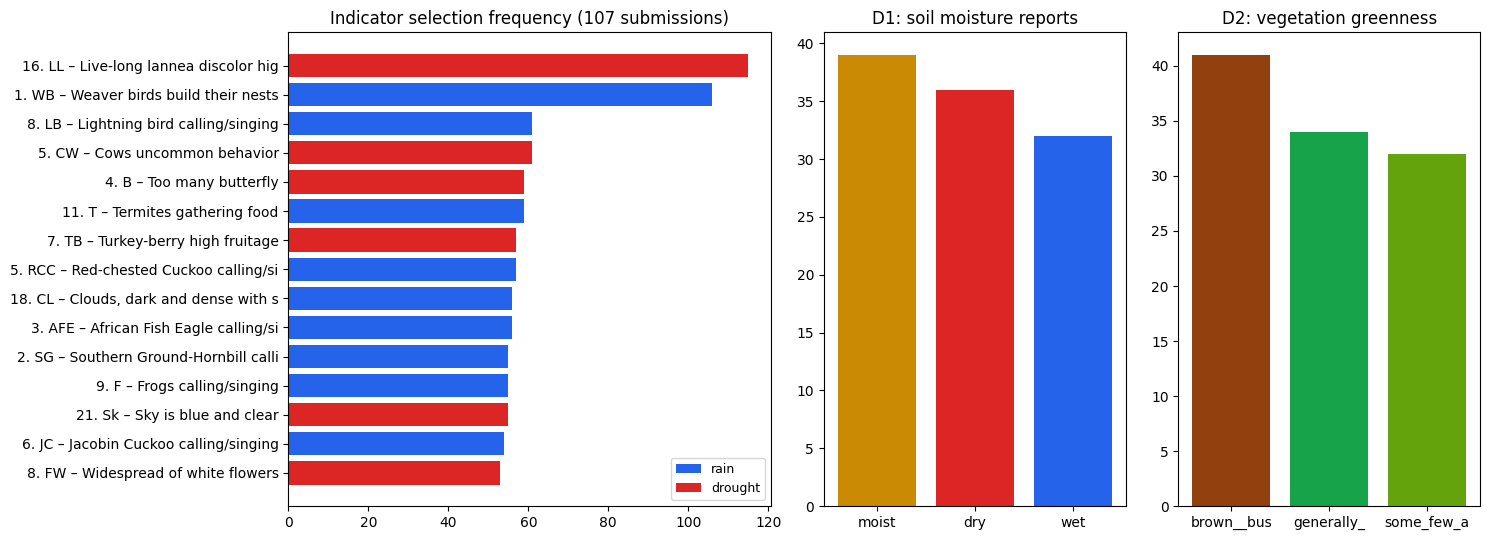


Daily net drought signal (drought − rain selections):
pol               drought  rain  net_drought
_submission_time                            
2026-05-07              5    10           -5
2026-05-11            539   988         -449


In [11]:
subs = pd.read_excel(SUBS)
subs['_submission_time'] = pd.to_datetime(subs['_submission_time'])

# Melt the one-hot select_multiple columns to long format (one row per selected indicator)
onehot = [c for c in subs.columns if '/' in c and c.split('/')[0].startswith(('B1_', 'C1_'))]
long = subs.melt(id_vars=['_id', '_submission_time',
                          'A2_Name_of_constitu_ndla_lokubikwa_ngayo',
                          'D1_How_is_the_soil_atsi_endzaweni_yakho',
                          'D2_How_is_the_veget_ato_endzaweni_yakho'],
                 value_vars=onehot, var_name='col', value_name='selected')
long = long[long['selected'] == 1].copy()
long['choice_name'] = long['col'].str.split('/').str[1]
long['code'] = (long['choice_name'].str.extract(r'^\d+__([a-z_]+?)___')[0]
                .str.upper().str.replace('_', '/', regex=False))
long = long.merge(matched[['code', 'label_en', 'group', 'pol']].drop_duplicates('code'), on='code', how='left')
print(f'{len(subs)} submissions -> {len(long)} indicator selections '
      f'({long.pol.value_counts().to_dict()})')

freq = long.groupby(['code', 'label_en', 'pol']).size().reset_index(name='n').sort_values('n')
POL_COLORS = {'rain': '#2563eb', 'drought': '#dc2626'}

fig, axes = plt.subplots(1, 3, figsize=(15, 5.5), width_ratios=[1.6, 1, 1])
top = freq.tail(15)
axes[0].barh(top['label_en'].str.slice(0, 38), top['n'], color=top['pol'].map(POL_COLORS))
axes[0].set_title(f'Indicator selection frequency (107 submissions)')
axes[0].legend(handles=[Patch(facecolor=c, label=p) for p, c in POL_COLORS.items()], fontsize=9)

soil = subs['D1_How_is_the_soil_atsi_endzaweni_yakho'].str.extract(r'^\d+__(\w+?)__')[0].value_counts()
axes[1].bar(soil.index, soil.values, color=['#ca8a04', '#dc2626', '#2563eb'])
axes[1].set_title('D1: soil moisture reports')

veg = subs['D2_How_is_the_veget_ato_endzaweni_yakho'].str.extract(r'^\d+__(\w+)')[0].value_counts()
axes[2].bar(veg.index.str.slice(0, 10), veg.values, color=['#92400e', '#16a34a', '#65a30d'])
axes[2].set_title('D2: vegetation greenness')
plt.tight_layout()
plt.show()

# Net drought-vs-rain signal — the real-data version of the prototype's weekly IKS trend
daily = long.groupby([long['_submission_time'].dt.date, 'pol']).size().unstack(fill_value=0)
daily['net_drought'] = daily.get('drought', 0) - daily.get('rain', 0)
print('\nDaily net drought signal (drought − rain selections):')
print(daily.to_string())

In [12]:
# Export tidy IKS datasets for the hub's v1_iks app (catalogue seeder + submission fixtures)
kobo_catalogue_out = matched[['group', 'code', 'label_en', 'pol', 'name']].rename(columns={'name': 'kobo_choice_name'})
kobo_catalogue_out.to_csv(OUT_IKS_CAT := Path('data/iks_kobo_catalogue.csv'), index=False)
long[['_id', '_submission_time', 'code', 'label_en', 'group', 'pol']].to_csv(
    OUT_IKS_SUB := Path('data/iks_kobo_submissions_long.csv'), index=False)
print(f'{OUT_IKS_CAT}: {len(kobo_catalogue_out)} indicators')
print(f'{OUT_IKS_SUB}: {len(long)} selections from {len(subs)} submissions')

data/iks_kobo_catalogue.csv: 29 indicators
data/iks_kobo_submissions_long.csv: 1542 selections from 107 submissions


## 5. CDI Explorer — 12-month indicator series

The prototype generates deterministic per-Inkhundla series (Jun 25 – May 26) for CHIRPS rainfall, NDVI, LST,
soil moisture, station rainfall, SPI-3 and IKS submissions, scaled by each Inkhundla's drought score.
Below: the top-priority Inkhundla vs the least-affected one.

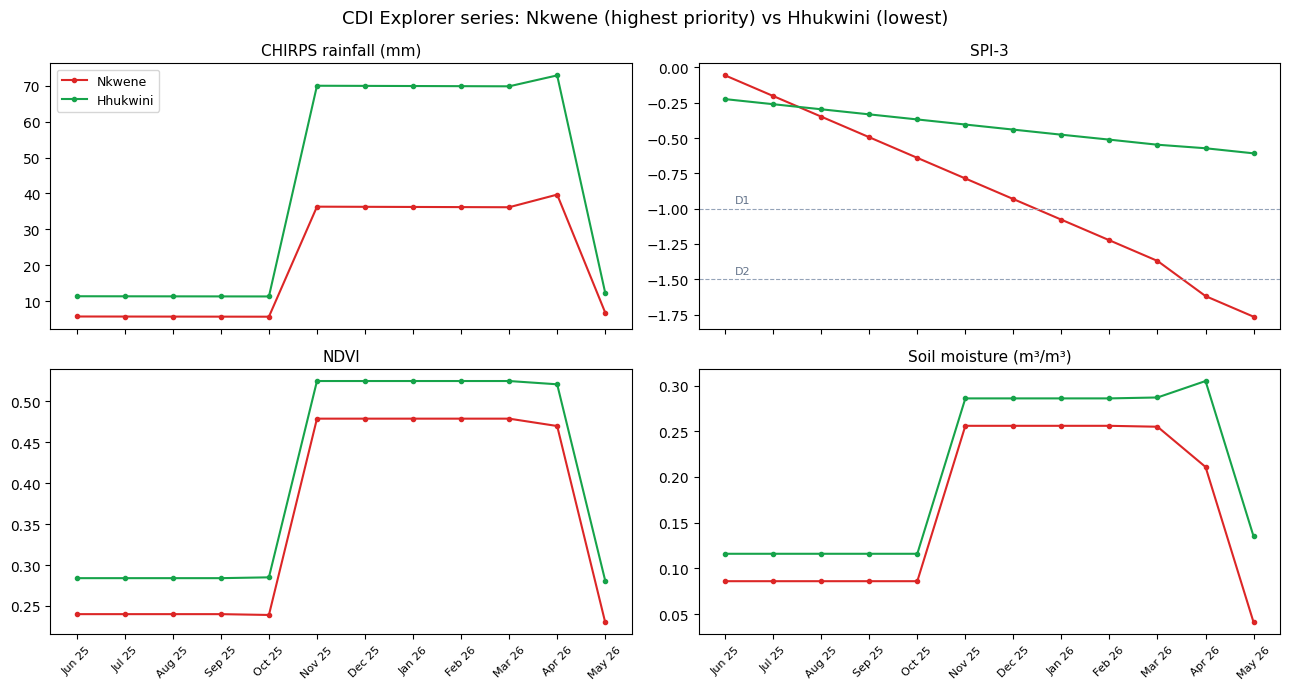

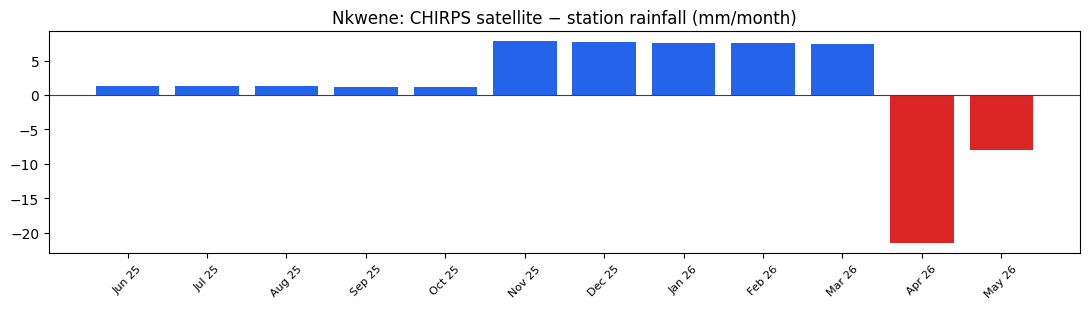

In [13]:
hi = pa.nlargest(1, 'priorityScore')['name'].iloc[0]
lo = pa.nsmallest(1, 'priorityScore')['name'].iloc[0]
months = series['month'].unique()

PANELS = [('chirps', 'CHIRPS rainfall (mm)'), ('spi3', 'SPI-3'), ('ndvi', 'NDVI'), ('smap', 'Soil moisture (m³/m³)')]
fig, axes = plt.subplots(2, 2, figsize=(13, 7), sharex=True)
for ax, (ind, title) in zip(axes.flat, PANELS):
    for name, color in [(hi, '#dc2626'), (lo, '#16a34a')]:
        s = series[(series['name'] == name) & (series['indicator'] == ind)]
        ax.plot(s['month'], s['value'], marker='o', markersize=3, label=name, color=color)
    ax.set_title(title, fontsize=11)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    if ind == 'spi3':
        for y, lbl in [(-1.0, 'D1'), (-1.5, 'D2')]:
            ax.axhline(y, color='#94a3b8', linestyle='--', linewidth=0.8)
            ax.text(0.2, y + 0.04, lbl, fontsize=8, color='#64748b')
axes[0, 0].legend(fontsize=9)
fig.suptitle(f'CDI Explorer series: {hi} (highest priority) vs {lo} (lowest)', fontsize=13)
plt.tight_layout()
plt.show()

# Satellite vs station rainfall delta — the disagreement the review workflow is built around
sat = series[(series['name'] == hi) & (series['indicator'] == 'chirps')].set_index('month')['value']
sta = series[(series['name'] == hi) & (series['indicator'] == 'precip_station')].set_index('month')['value']
fig, ax = plt.subplots(figsize=(11, 3.2))
ax.bar(months, sat - sta.reindex(sat.index), color=np.where(sat >= sta.reindex(sat.index), '#2563eb', '#dc2626'))
ax.axhline(0, color='#374151', linewidth=0.8)
ax.set_title(f'{hi}: CHIRPS satellite − station rainfall (mm/month)')
ax.tick_params(axis='x', rotation=45, labelsize=8)
plt.tight_layout()
plt.show()

## Summary

- **Priority model verified**: the Python port reproduces the prototype's drought × exposure × vulnerability scores to
  floating-point precision for all 59 Tinkhundla, including the urgent / watch / monitor action bands.
- **SOP triggers verified**: the 7 rule-based SOPs re-encoded in Python reproduce all 413 prototype trigger decisions.
  The activation heatmap shows which Tinkhundla would receive which interventions under current conditions.
- **Review queue**: the stored `combined_delta` equals `|ΔSPI| + |ΔLST|` (note: the *legacy* `_rvDeltaConfidence`
  formula in the code halves the LST term — the new review-queue data does not). Station-confidence tiers follow
  **< 0.5 High, < 1.0 Medium, else Low** (100% reproduction). Suggested D-class values are bumped ±1 class in the
  direction the station disagrees.
- **IKS & CDI Explorer** series are deterministic mock generators (hash-seeded), scaled by each Inkhundla's drought
  score — useful as placeholders until real EO time series and IKS submissions are wired in (see
  `eswatini_drought_analysis.ipynb` for the real July-2025 CDI raster workflow).

**Datasets** live in `data/prototype/` (CSV + JSON), regenerable any time with
`node scripts/extract_prototype_data.mjs`.